## Week 1 task

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()
df.shape
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


np.int64(0)

## WEEK 2 – DATA CLEANING

In [3]:
df.info()
df.isnull().sum()
(df.isnull().sum()/len(df))*100
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


np.int64(0)

In [4]:
df['type'].unique()
df['rating'].unique()
df['country'].unique()
df['type'].value_counts()
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [5]:
df[df['rating'].str.contains('min', na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [6]:
mask = df['rating'].str.contains('min', na=False)

df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = None

In [7]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [9]:
df['director'] = df['director'].fillna('Unknown')

In [10]:
df['cast'] = df['cast'].fillna('Unknown')

In [11]:
df['country'] = df['country'].fillna('Not Available')

In [12]:
df['rating'] = df['rating'].fillna("Not Rated")

In [13]:
df.dropna(subset=['date_added'], inplace=True)

In [14]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Week-3: Normalization of Categorical Features

In [15]:
df['type'].unique()
df['rating'].unique()
df['country'].head()

0    United States
1     South Africa
2    Not Available
3    Not Available
4            India
Name: country, dtype: object

In [16]:
df['type'].value_counts()
df['rating'].value_counts()

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
Not Rated       7
TV-Y7-FV        6
NC-17           3
UR              3
Name: count, dtype: int64

In [17]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [18]:
df['type'] = df['type'].str.title()
df['rating'] = df['rating'].str.upper()
df['country'] = df['country'].str.title()

In [19]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [20]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract('([A-Za-z]+)')

In [21]:
df['listed_in'] = df['listed_in'].apply(lambda x: [i.strip() for i in x.split(',')])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(11)
memory usage: 1.0+ MB


In [23]:
df.reset_index(drop=True, inplace=True)

In [24]:
df['listed_in'] = df['listed_in'].apply(
    lambda x: [i.strip() for i in x.split(',')] if isinstance(x, str) else x
)

In [25]:
df['release_year'].describe()
df['duration_num'].describe()

count    8797.000000
mean       69.921792
std        50.788599
min         1.000000
25%         2.000000
50%        88.000000
75%       106.000000
max       312.000000
Name: duration_num, dtype: float64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(11)
memory usage: 962

In [27]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [28]:
df['year_added'] = df['year_added'].astype(int)
df['month_added'] = df['month_added'].astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
 14  year_added     8797 non-null   int64         
 15  month_added    8797 n

In [30]:
original = pd.read_csv("netflix_titles.csv", usecols=['listed_in'])

In [31]:
df['listed_in'] = original['listed_in']

In [32]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
 14  year_added     8797 non-null   int64         
 15  month_added    8797 n

In [34]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [35]:
df['type'] = df['type'].str.title()
df['country'] = df['country'].str.title()
df['rating'] = df['rating'].str.upper()

In [36]:
df[['duration','duration_num','duration_type']].head()

,duration,duration_num,duration_type
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
 14  year_added     8797 non-null   int64         
 15  month_added    8797 n

## Week-4

In [39]:
content_per_year = df['year_added'].value_counts().sort_index()

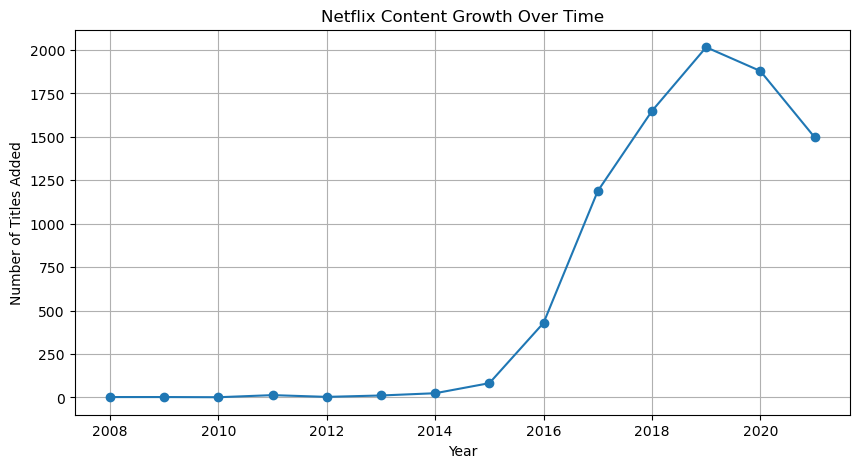

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(content_per_year.index, content_per_year.values, marker='o')

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True)
plt.show()

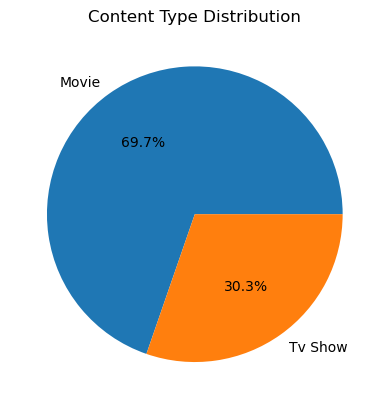

In [64]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Content Type Distribution")
plt.ylabel("")

plt.show()

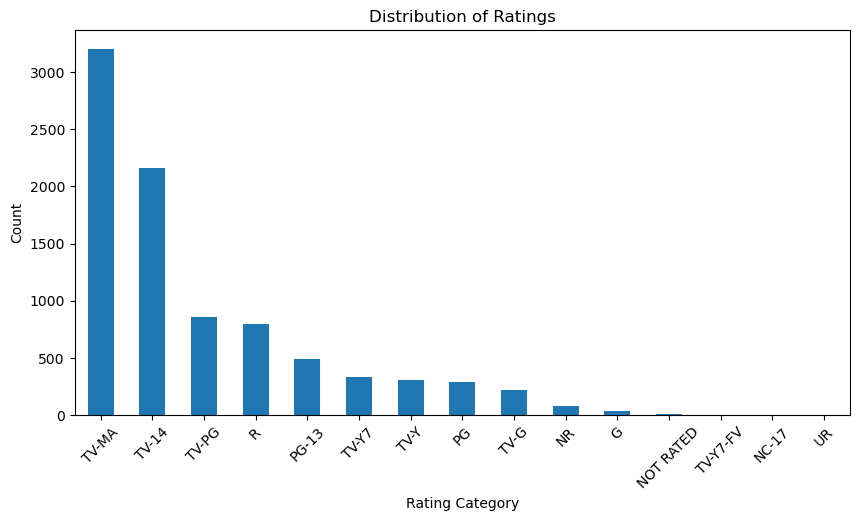

In [42]:
df['rating'].value_counts().plot(kind='bar', figsize=(10,5))

plt.title("Distribution of Ratings")
plt.xlabel("Rating Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [43]:
country_counts = df[df['country'] != 'Not Available']['country'].value_counts().head(10)
country_counts

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

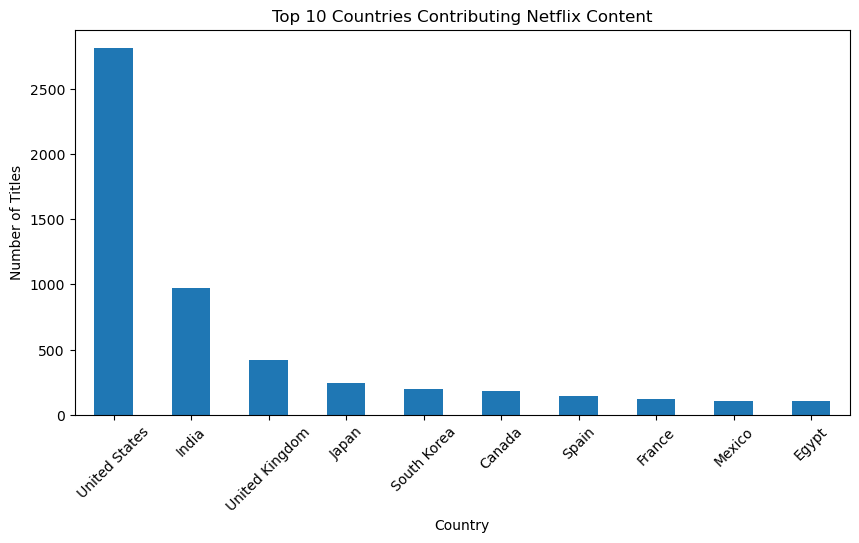

In [44]:
import matplotlib.pyplot as plt

country_counts.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Countries Contributing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

In [45]:
def length_category(x):
    if x < 60:
        return "Short"
    elif x <= 120:
        return "Medium"
    else:
        return "Long"

df['content_length_category'] = df['duration_num'].apply(length_category)

In [46]:
df['content_length_category'].value_counts()

content_length_category
Medium    4531
Short     3124
Long      1142
Name: count, dtype: int64

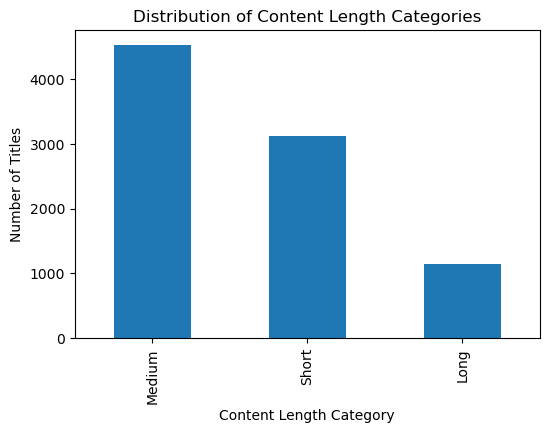

In [47]:
import matplotlib.pyplot as plt

df['content_length_category'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title("Distribution of Content Length Categories")
plt.xlabel("Content Length Category")
plt.ylabel("Number of Titles")

plt.show()

In [48]:
df['content_origin'] = df.apply(
    lambda x: "Netflix Original"
    if "netflix" in str(x['description']).lower() or "netflix" in str(x['title']).lower()
    else "Licensed",
    axis=1
)

In [49]:
df['content_origin'].value_counts()

content_origin
Licensed            8785
Netflix Original      12
Name: count, dtype: int64

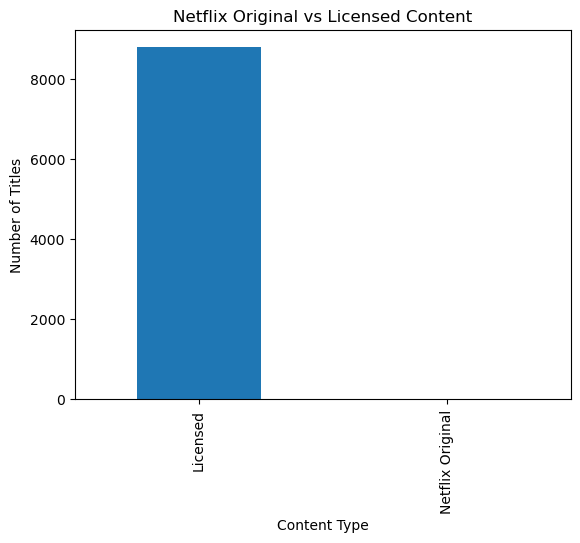

In [50]:
import matplotlib.pyplot as plt

df['content_origin'].value_counts().plot(kind='bar')

plt.title("Netflix Original vs Licensed Content")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [66]:
genres = df['listed_in'].str.split(', ').explode()

In [67]:
top_genres = genres.value_counts().head(10)

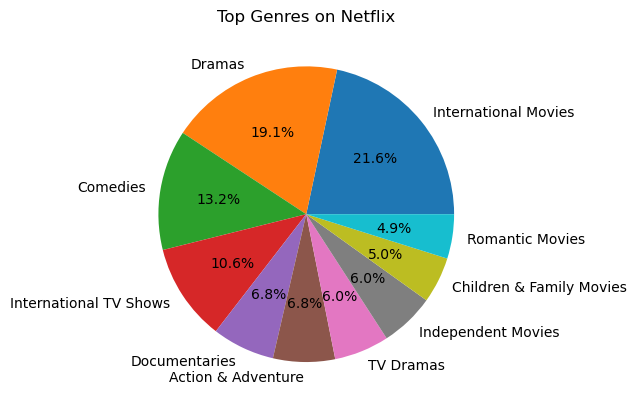

In [68]:
top_genres.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top Genres on Netflix")
plt.ylabel("")

plt.show()

## Week-5

Clustering Netflix Titles

In [51]:
features = df[['duration_num','year_added','month_added']]

In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'])

features = df[['duration_num','year_added','month_added','rating_encoded']]

In [53]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(features)

In [54]:
df['cluster'].value_counts()

cluster
2    3990
0    2915
1    1892
Name: count, dtype: int64

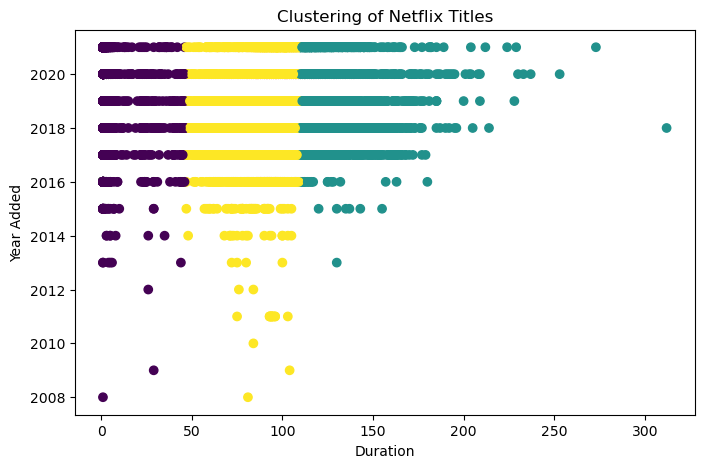

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df['duration_num'], df['year_added'], c=df['cluster'], cmap='viridis')

plt.xlabel("Duration")
plt.ylabel("Year Added")
plt.title("Clustering of Netflix Titles")

plt.show()

Classification (Movie vs TV Show)

In [56]:
df['type_encoded'] = df['type'].map({'Movie':0, 'Tv Show':1})

In [57]:
df[['type','type_encoded']].head()

,type,type_encoded
0,Movie,0
1,Tv Show,1
2,Tv Show,1
3,Tv Show,1
4,Tv Show,1


In [58]:
X = df[['duration_num','year_added','month_added','rating_encoded']]
y = df['type_encoded']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)


0.9982954545454545

In [63]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[1226,    3],
       [   0,  531]])